# H-001 · S2 Universes A–F Discovery + Baseline Backtest

**Decides:** `UNIVERSE_STAR` and the freeze book that represents it (≤6 pairs, ≤2 per pool, from EG passers). Not the full passer set. Health / rotate / half-life are H-003 / H-004 / H-008.

Screens every registered universe and picks `UNIVERSE_STAR`.

| Universe | What | Status |
|----------|------|--------|
| A | FX majors (OANDA) | failed previously — 0 EG passers |
| B | Crypto majors (Kraken) | failed previously — best pair HL > `Z_WINDOW` |
| C | Asia EM cash equities (IBKR HK/JP) | **shelved** — gross Sharpe ≈ 0, net negative after 271–439 bps/yr |
| D | US share-class twins (Alpaca) | **shelved** — WSO.B not shortable on Alpaca or IBKR; WSO|WSO.B delivered the entire book return |
| E | US REIT sub-sectors (Alpaca) | candidate |
| F | EUR large caps (IBKR EUR) | candidate |

A / B / C / D are re-run **for the record only** and are documented learning points in
`02_research/s2_coint/universe.md`. They are not re-selected. E / F compete for
`UNIVERSE_STAR`.

## Workflow

1. Alpaca shortability for US names (skip `SKIP_SHORTABILITY_UNIVERSES`), then pool-scoped candidate screening via `iter_pool_pairs` at each universe's fixed `RESEARCH_IS_END`
2. Show **all** EG passers with `auto_selected` / `exclude_reason` (caps 6 / 2); `select_book` is a suggestion only
3. Research-IS trad-z diagnostics on **all** EG passers (incl. `pct_adf_lt_threshold`) + ADF health overlap
4. Documented **`MANUAL_BOOK`** lock under the same caps → export `s2_pairs_{letter}_1d.csv` and `s2_candidates_{letter}_1d.csv`
5. Book-level gross vs net Sharpe and correlation to S1 on the **manual** freeze books

Candidates come **only** from within a leaf pool (`S2_POOLS` in
`01_data/processing/s2_universe_pools.py`), at any nesting depth.

## Conventions

- **Research IS only** (`date <= RESEARCH_IS_END`). Do not score sealed OOS here.
- Scored under the `freeze` convention with **soft defaults** (`ols=252`, `z=60`, `entry_z=2`),
  since H-003 (`BREAK_STAR`) and H-004 (`BOOK_STAR`) have not run yet — so **no break gate**.
- Discovery ranks on **p-value**; half-life and `pct_adf_lt_threshold` are **inspection only** (no gate before H-008 / H-003).
- Rank universes on **net Sharpe** and read correlation beside it. **A negative correlation to S1
  is strictly better than a low positive one** (−0.2 beats 0.0), because it adds diversification
  rather than merely avoiding overlap. No combined score.
- Short-selling bans are enforced for F via `strategies.s2_coint.short_bans`; A–E have no records.
- Alpaca shortability: query every universe **except** `SKIP_SHORTABILITY_UNIVERSES` (currently `["F"]`), and only tickers with `ticker_venue_key == "US"`. Gate is `shortable`; `easy_to_borrow` is displayed, not a gate (`shortable=True` / `easy_to_borrow=False` = HTB, kept). Not-found → not shortable. Non-shortable tickers (and every pair containing them) are dropped before EG screening.
- **F cost caveat:** `F_EUR_IBKR` is an assumption pending IBKR's European cash-equity schedule.
  Confirm it before treating F's net Sharpe as decision-grade.

**Run order:** run this notebook **first**, then
`01_data/data_files/s2_coint/s2_pair_panel.ipynb` to build the panels.


## 0. Imports & Config

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.diagnosis import gross_returns_from_net
from backtest.s2_coint.research import candidates_path, pairs_path
from backtest.s2_coint.rotation import simulate_frozen_book
from data.ingestion.equity_fetcher import fetch_ohlcv
from data.processing.feature_implementation.cointegration import COINT_PVALUE
from data.processing.s2_coint_store import build_pair_panel, screen_pair_cointegration
from data.processing.s2_universe import (
    RESEARCH_IS_END_BY_UNIVERSE,
    SHELVED_UNIVERSES,
    iter_pool_pairs,
    load_s2_pools,
    pool_of_pair,
    pool_tickers,
    ticker_venue_key,
)
from strategies.s2_coint.baseline import (
    BETA_COLUMN,
    ENTRY_Z,
    EXIT_Z,
    USE_HEDGE_RATIO_SIZING,
    clip_ohlc_to_is,
)
from strategies.s2_coint.book import (
    CAP_GLOBAL,
    CAP_PER_POOL,
    SLOT_WEIGHT,
    annotate_screen,
    select_book,
    validate_manual_book,
)
from execution.brokers.alpaca_broker import (
    AlpacaBroker,
    S2_ALPACA_API_KEY,
    S2_ALPACA_SECRET_KEY,
)
from strategies.s2_coint.config import S2SimConfig
from strategies.s2_coint.metrics import (
    adf_health_masks,
    adf_pairwise_overlap,
    adf_union_coverage,
    corr_to_s1,
    diagnose_locked_panel,
    load_s1_period_returns,
    metrics_from_returns,
    metrics_from_returns_inference,
)

DATA_DIR = os.path.join(ROOT, "01_data", "data_files", "s2_coint")
S1_RETURNS_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_period_returns.parquet"
)

UNIVERSE_LABELS = ("A", "B", "C", "D", "E", "F")
BAR = "1d"
FETCH_START = "1990-01-01"
END_DATE = None
RESEARCH_IS_END = dict(RESEARCH_IS_END_BY_UNIVERSE)

COINT_PVALUE_THRESHOLD = 0.05
OLS_WINDOW = 252
Z_WINDOW = 60
HL_WINDOW = 252
ADF_PVALUE_THRESHOLD = COINT_PVALUE

# None = shelved (A–D). [] = not yet chosen (E/F; must not fall back to auto).
MANUAL_BOOK = {"A": None, "B": None, "C": None, "D": None, "E": [], "F": []}
SKIP_SHORTABILITY_UNIVERSES = ["F"]

SIM_KW = dict(
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    beta_column=BETA_COLUMN,
    use_hedge_ratio_sizing=USE_HEDGE_RATIO_SIZING,
)
# Soft defaults: no break gate, since BREAK_STAR is not frozen until H-003.
BOOK_CFG = S2SimConfig(
    bar=BAR,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    ols_window=OLS_WINDOW,
    z_window=Z_WINDOW,
    hl_window=HL_WINDOW,
    adf_window=OLS_WINDOW,
    break_mode="off",
)

POOLS = {label: load_s2_pools(label) for label in UNIVERSE_LABELS}
CANDIDATES = {label: iter_pool_pairs(POOLS[label]) for label in UNIVERSE_LABELS}
POOL_OF_PAIR = {label: pool_of_pair(POOLS[label]) for label in UNIVERSE_LABELS}

for label in UNIVERSE_LABELS:
    flag = "  (shelved - record only)" if label in SHELVED_UNIVERSES else ""
    print(
        f"{label}: {len(pool_tickers(POOLS[label])):3d} tickers  "
        f"{len(CANDIDATES[label]):3d} candidate pairs  IS end {RESEARCH_IS_END[label]}{flag}"
    )
print("\ntotal candidates:", sum(len(v) for v in CANDIDATES.values()))
print("caps: global", CAP_GLOBAL, "| per pool", CAP_PER_POOL)
print("MANUAL_BOOK:", {k: (None if v is None else list(v)) for k, v in MANUAL_BOOK.items()})


A:   6 tickers   15 candidate pairs  IS end 2020-12-31  (shelved - record only)
B:   4 tickers    6 candidate pairs  IS end 2022-12-31  (shelved - record only)
C:  11 tickers   16 candidate pairs  IS end 2021-12-31  (shelved - record only)
D:  20 tickers   10 candidate pairs  IS end 2021-12-31  (shelved - record only)
E:  28 tickers   54 candidate pairs  IS end 2021-12-31
F:  26 tickers   38 candidate pairs  IS end 2021-12-31

total candidates: 139
caps: global 6 | per pool 2
MANUAL_BOOK: {'A': None, 'B': None, 'C': None, 'D': None, 'E': [], 'F': []}


## 1. Load pools and fetch OHLCV

`isAsian=True` keeps the exchange-suffix dot for `.HK` / `.T` / `.MC` / `.MI` / `.AS` / `.DE` /
`.PA`. US names, **including share classes such as `BF.B`**, must stay `isAsian=False` so the fetcher
hyphenates them to Yahoo's `BF-B`.

In [2]:
ohlc_by_universe: dict[str, dict[str, pd.DataFrame]] = {}
closes_by_universe: dict[str, dict[str, pd.Series]] = {}

for label in UNIVERSE_LABELS:
    ohlc: dict[str, pd.DataFrame] = {}
    closes: dict[str, pd.Series] = {}
    print(f"\n=== Universe {label} ===")
    for ticker in pool_tickers(POOLS[label]):
        is_suffixed = "." in ticker and ticker_venue_key(ticker) != "US"
        panel = fetch_ohlcv(
            ticker,
            start_date=FETCH_START,
            end_date=END_DATE,
            isAsian=is_suffixed,
            interval=BAR,
        )
        if panel is None or panel.empty:
            print(f"WARNING: no OHLCV for {ticker} ({label})")
            continue
        frame = (
            panel.sort_values("date")
            .drop_duplicates("date", keep="last")
            .set_index("date")[["open", "high", "low", "close"]]
            .astype(float)
        )
        frame.index = pd.to_datetime(frame.index)
        frame = frame.dropna(subset=["close"])
        if frame.empty:
            print(f"WARNING: no valid closes for {ticker} ({label})")
            continue
        ohlc[ticker] = frame
        closes[ticker] = frame["close"].copy()
        print(
            f"{ticker:12} bars={len(frame):5d} venue={ticker_venue_key(ticker)} "
            f"[{frame.index.min().date()} .. {frame.index.max().date()}]"
        )
    ohlc_by_universe[label] = ohlc
    closes_by_universe[label] = closes


=== Universe A ===
AUDUSD=X     bars= 5282 venue=FX [2006-05-16 .. 2026-09-04]
NZDUSD=X     bars= 5907 venue=FX [2003-12-01 .. 2026-09-04]
EURUSD=X     bars= 5906 venue=FX [2003-12-01 .. 2026-09-04]
GBPUSD=X     bars= 5918 venue=FX [2003-12-01 .. 2026-09-04]
USDCHF=X     bars= 5972 venue=FX [2003-09-17 .. 2026-09-04]
USDJPY=X     bars= 7740 venue=FX [1996-10-30 .. 2026-09-04]

=== Universe B ===
BTC-USD      bars= 4371 venue=CRYPTO [2014-09-17 .. 2026-09-04]
ETH-USD      bars= 3222 venue=CRYPTO [2017-11-09 .. 2026-09-04]
SOL-USD      bars= 2339 venue=CRYPTO [2020-04-10 .. 2026-09-04]
BNB-USD      bars= 3222 venue=CRYPTO [2017-11-09 .. 2026-09-04]

=== Universe C ===
0939.HK      bars= 5142 venue=HK [2005-10-27 .. 2026-09-04]
1398.HK      bars= 4893 venue=HK [2006-10-27 .. 2026-09-04]
3988.HK      bars= 4998 venue=HK [2006-06-01 .. 2026-09-04]
1288.HK      bars= 3977 venue=HK [2010-07-16 .. 2026-09-04]
3328.HK      bars= 5229 venue=HK [2005-06-23 .. 2026-09-04]
0857.HK      bars= 6580 

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CWEN-A"}}}
$CWEN-A: possibly delisted; no timezone found

1 Failed download:
['CWEN-A']: possibly delisted; no timezone found
yfinance returned empty for chunk ['CWEN-A'] (attempt 1/5)
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CWEN-A"}}}
$CWEN-A: possibly delisted; no timezone found

1 Failed download:
['CWEN-A']: possibly delisted; no timezone found
yfinance returned empty for chunk ['CWEN-A'] (attempt 2/5)
$CWEN-A: possibly delisted; no timezone found

1 Failed download:
['CWEN-A']: possibly delisted; no timezone found
yfinance returned empty for chunk ['CWEN-A'] (attempt 3/5)
$CWEN-A: possibly delisted; no timezone found

1 Failed download:
['CWEN-A']: possibly delisted; no timezone found
yfinance returned empty for chunk ['CWEN-A'] (attempt 4/5)
$CWEN-A: possibly delisted; no timezone found


WSO          bars= 9237 venue=US [1990-01-02 .. 2026-09-04]
WSO.B        bars= 9236 venue=US [1990-01-02 .. 2026-09-03]
GEF          bars= 7680 venue=US [1996-02-28 .. 2026-09-04]
GEF.B        bars= 5765 venue=US [2003-10-07 .. 2026-09-04]

=== Universe E ===
AMT          bars= 7175 venue=US [1998-02-27 .. 2026-09-04]
CCI          bars= 7056 venue=US [1998-08-18 .. 2026-09-04]
SBAC         bars= 6848 venue=US [1999-06-16 .. 2026-09-04]
PSA          bars= 9237 venue=US [1990-01-02 .. 2026-09-04]
EXR          bars= 5550 venue=US [2004-08-16 .. 2026-09-04]
CUBE         bars= 5502 venue=US [2004-10-22 .. 2026-09-04]
NSA          bars=    1 venue=US [2026-07-17 .. 2026-07-17]
O            bars= 8024 venue=US [1994-10-18 .. 2026-09-04]
NNN          bars= 9237 venue=US [1990-01-02 .. 2026-09-04]
ADC          bars= 8152 venue=US [1994-04-15 .. 2026-09-04]
WPC          bars= 7201 venue=US [1998-01-21 .. 2026-09-04]
EPRT         bars= 2063 venue=US [2018-06-21 .. 2026-09-04]
PLD          bars= 7

## 1.1 Alpaca shortability

Query every universe **except** `SKIP_SHORTABILITY_UNIVERSES` (currently `["F"]`), and only tickers with `ticker_venue_key == "US"`. Gate is `shortable`; `easy_to_borrow` is displayed, not a gate (`shortable=True` / `easy_to_borrow=False` = HTB, kept). Not-found assets are treated as not shortable. Non-shortable tickers, and every pair containing them, are dropped from `CANDIDATES` before EG screening.

In [3]:
shortability_by_ticker: dict[str, dict] = {}
non_shortable_tickers: set[str] = set()

to_check: list[str] = []
_seen: set[str] = set()
for label in UNIVERSE_LABELS:
    if label in SKIP_SHORTABILITY_UNIVERSES:
        continue
    for t in pool_tickers(POOLS[label]):
        if ticker_venue_key(t) != "US" or t in _seen:
            continue
        _seen.add(t)
        to_check.append(t)

for label in SKIP_SHORTABILITY_UNIVERSES:
    print(f"{label}: skipped (in SKIP_SHORTABILITY_UNIVERSES)")

if to_check:
    broker = AlpacaBroker(
        paper=True,
        api_key_name=S2_ALPACA_API_KEY,
        secret_key_name=S2_ALPACA_SECRET_KEY,
    )
    rows = broker.get_asset_shortability(to_check)
    short_df = pd.DataFrame(rows)
    short_df["shortable_not_etb"] = (
        short_df["shortable"].astype(bool) & ~short_df["easy_to_borrow"].astype(bool)
    )
    shortability_by_ticker = {row["ticker"]: row for row in rows}
    display(
        short_df[
            [
                "ticker",
                "alpaca_symbol",
                "shortable",
                "easy_to_borrow",
                "found",
                "error",
                "shortable_not_etb",
            ]
        ]
    )
    n = len(short_df)
    n_shortable = int(short_df["shortable"].sum())
    n_not_shortable = int((~short_df["shortable"].astype(bool)).sum())
    n_etb = int(short_df["easy_to_borrow"].sum())
    n_shortable_not_etb = int(short_df["shortable_not_etb"].sum())
    print(
        f"n={n}  n_shortable={n_shortable}  n_not_shortable={n_not_shortable}  "
        f"n_etb={n_etb}  n_shortable_not_etb={n_shortable_not_etb}"
    )
    non_shortable_list = sorted(
        t for t, r in shortability_by_ticker.items() if not r["shortable"]
    )
    htb_list = sorted(
        t
        for t, r in shortability_by_ticker.items()
        if r["shortable"] and not r["easy_to_borrow"]
    )
    print("Non-shortable (dropped from screening):", non_shortable_list)
    print("Shortable but not easy_to_borrow (kept, HTB):", htb_list)
else:
    print("no US tickers to check")

non_shortable_tickers = {
    t for t, r in shortability_by_ticker.items() if not r["shortable"]
}
for label in UNIVERSE_LABELS:
    if label in SKIP_SHORTABILITY_UNIVERSES:
        continue
    before = list(CANDIDATES[label])
    kept = [
        (a, b)
        for a, b in before
        if a not in non_shortable_tickers and b not in non_shortable_tickers
    ]
    CANDIDATES[label] = kept
    kept_set = set(kept)
    dropped = [f"{a}|{b}" for a, b in before if (a, b) not in kept_set]
    print(f"{label}: dropped {len(dropped)} pairs: {dropped}")

F: skipped (in SKIP_SHORTABILITY_UNIVERSES)


,ticker,alpaca_symbol,shortable,easy_to_borrow,found,error,shortable_not_etb
0,GOOGL,GOOGL,True,True,True,,False
1,GOOG,GOOG,True,True,True,,False
2,FOXA,FOXA,True,True,True,,False
3,FOX,FOX,True,True,True,,False
4,NWSA,NWSA,True,True,True,,False
5,NWS,NWS,True,True,True,,False
6,UAA,UAA,True,True,True,,False
7,UA,UA,True,True,True,,False
8,BF.A,BF.A,True,True,True,,False
9,BF.B,BF.B,True,True,True,,False


n=48  n_shortable=42  n_not_shortable=6  n_etb=42  n_shortable_not_etb=0
Non-shortable (dropped from screening): ['AVB', 'CWEN.A', 'EQR', 'GEF.B', 'NSA', 'WSO.B']
Shortable but not easy_to_borrow (kept, HTB): []
A: dropped 0 pairs: []
B: dropped 0 pairs: []
C: dropped 0 pairs: []
D: dropped 3 pairs: ['CWEN|CWEN.A', 'WSO|WSO.B', 'GEF|GEF.B']
E: dropped 12 pairs: ['NSA|PSA', 'EXR|NSA', 'CUBE|NSA', 'AVB|EQR', 'AVB|ESS', 'AVB|MAA', 'AVB|CPT', 'AVB|UDR', 'EQR|ESS', 'EQR|MAA', 'CPT|EQR', 'EQR|UDR']


## 2. Research IS cutoff

Pre-registered calendar `RESEARCH_IS_END` per universe (no fraction of dates). Screen and train both
use `date <= T`. D / E / F are all `2021-12-31`, so cross-universe comparison is apples-to-apples
with ~14 quarters of sealed OOS left for H-004's rotating book.

In [4]:
is_end_by_universe: dict[str, pd.Timestamp] = {}
for label in UNIVERSE_LABELS:
    is_end_by_universe[label] = pd.Timestamp(RESEARCH_IS_END[label])
    print(f"{label}: RESEARCH_IS_END={is_end_by_universe[label].date()}")

A: RESEARCH_IS_END=2020-12-31
B: RESEARCH_IS_END=2022-12-31
C: RESEARCH_IS_END=2021-12-31
D: RESEARCH_IS_END=2021-12-31
E: RESEARCH_IS_END=2021-12-31
F: RESEARCH_IS_END=2021-12-31


## 3. Pool-scoped screening (fixed `RESEARCH_IS_END`)

Engle-Granger on `date <= T` for candidates **within leaf pools only**. `eligible=False` means too
few mutual IS bars — that is a data gap, not an EG failure. The screen tests both `y~x` and `x~y`
and orients `pair_id` by the lower p-value.

Display **every** EG passer (`pvalue < 0.05`) with `auto_selected` / `exclude_reason` from the same
cap walk as `select_book`. Half-life is inspection-only. Non-passers stay in the candidates CSV.


In [5]:
screened_by_universe: dict[str, pd.DataFrame] = {}
annotated_by_universe: dict[str, pd.DataFrame] = {}

for label in UNIVERSE_LABELS:
    closes = closes_by_universe[label]
    candidates = [
        (a, b) for a, b in CANDIDATES[label] if a in closes and b in closes
    ]
    print(f"\n=== Universe {label}: {len(candidates)} screenable candidates ===")
    screened = screen_pair_cointegration(
        closes,
        candidates,
        is_end=is_end_by_universe[label],
        ols_window=OLS_WINDOW,
        pvalue_threshold=COINT_PVALUE_THRESHOLD,
    )
    screened_by_universe[label] = screened
    if screened.empty:
        annotated_by_universe[label] = screened
        print("  no screenable candidates")
        continue

    annotated = annotate_screen(
        screened,
        pool_of_pair=POOL_OF_PAIR[label],
        per_pool_cap=CAP_PER_POOL,
        global_cap=CAP_GLOBAL,
        pvalue_threshold=COINT_PVALUE_THRESHOLD,
    )
    annotated_by_universe[label] = annotated

    n_elig = int(annotated["eligible"].sum())
    passer_mask = annotated["eligible"] & (annotated["pvalue"] < COINT_PVALUE_THRESHOLD)
    n_pass = int(passer_mask.sum())
    n_auto = int(annotated["auto_selected"].sum())
    print(f"  eligible {n_elig}/{len(annotated)}  EG passers {n_pass}  auto-selected {n_auto}")
    n_fail = int((~passer_mask).sum())
    print(f"  non-passers (CSV only): {n_fail}")

    cols = [
        "pair_id",
        "pool",
        "pvalue",
        "discovery_half_life",
        "n_is_bars",
        "auto_selected",
        "exclude_reason",
    ]
    display(annotated.loc[passer_mask].sort_values("pvalue")[cols])



=== Universe A: 15 screenable candidates ===
  eligible 15/15  EG passers 0  auto-selected 0
  non-passers (CSV only): 15


,pair_id,pool,pvalue,discovery_half_life,n_is_bars,auto_selected,exclude_reason



=== Universe B: 6 screenable candidates ===
  eligible 6/6  EG passers 0  auto-selected 0
  non-passers (CSV only): 6


,pair_id,pool,pvalue,discovery_half_life,n_is_bars,auto_selected,exclude_reason



=== Universe C: 16 screenable candidates ===
  eligible 16/16  EG passers 9  auto-selected 3
  non-passers (CSV only): 7


...

,pair_id,pool,pvalue,discovery_half_life,n_is_bars,auto_selected,exclude_reason
6,HEI|HEI.A,heico,0.000437,15.659791,5962,True,
2,NWS|NWSA,news_corp,0.012650,12.438238,2151,True,



=== Universe E: 42 screenable candidates ===
  eligible 42/42  EG passers 12  auto-selected 6
  non-passers (CSV only): 30


,pair_id,pool,pvalue,discovery_half_life,n_is_bars,auto_selected,exclude_reason
0,CCI|AMT,towers,3.083666e-08,21.380019,5883,True,
6,O|NNN,net_lease,5.201699e-04,16.631919,6851,True,
38,SBRA|VTR,healthcare,8.431056e-04,40.046949,4975,True,
40,SBRA|OHI,healthcare,2.455586e-03,23.539240,4975,True,
2,SBAC|CCI,towers,2.574411e-03,41.639937,5675,True,
35,SBRA|WELL,healthcare,3.074880e-03,34.072487,4975,False,pool_cap
19,PLD|TRNO,industrial,8.323206e-03,21.285427,2995,True,
1,SBAC|AMT,towers,1.029821e-02,43.163741,5675,False,pool_cap
3,PSA|EXR,self_storage,3.232805e-02,13.250798,4377,False,global_cap
11,NNN|WPC,net_lease,3.994732e-02,20.098370,6028,False,global_cap



=== Universe F: 38 screenable candidates ===
  eligible 38/38  EG passers 9  auto-selected 6
  non-passers (CSV only): 29


,pair_id,pool,pvalue,discovery_half_life,n_is_bars,auto_selected,exclude_reason
17,UCG.MI|BAMI.MI,MI.it_banks,2.905086e-09,37.533023,5627,True,
18,UCG.MI|BPE.MI,MI.it_banks,4.045165e-07,22.125704,5627,True,
19,UCG.MI|BMPS.MI,MI.it_banks,4.282105e-06,30.458988,5627,False,pool_cap
13,UCG.MI|ISP.MI,MI.it_banks,5.762231e-06,25.628375,5627,False,pool_cap
21,BMPS.MI|BAMI.MI,MI.it_banks,4.076092e-03,65.421784,5627,False,pool_cap
26,ASML.AS|ASM.AS,AS.nl_semis,1.797195e-02,36.775114,5921,True,
27,ASML.AS|BESI.AS,AS.nl_semis,1.968128e-02,26.925699,6043,True,
25,SRG.MI|TRN.MI,MI.it_regulated_utilities,1.974450e-02,28.002768,4460,True,
37,KER.PA|OR.PA,PA.fr_luxury,4.902129e-02,50.420414,5658,True,


## 4. Auto `select_book` suggestion (caps 6 / 2)

`select_book` ranks EG passers by p-value, then applies the **per-pool cap (2)** before the
**global cap (6)**. This is a **suggestion only** — the freeze book is locked in section 8 via
`MANUAL_BOOK`. An unordered pair occupies one slot regardless of orientation.

The per-pool cap is what stops a single factor filling the book — the failure mode that sank C,
where all locked pairs loaded one China-bank factor.


In [6]:
auto_by_universe: dict[str, pd.DataFrame] = {}
passer_pairs_by_universe: dict[str, list[tuple[str, str]]] = {}

for label in UNIVERSE_LABELS:
    screened = screened_by_universe[label]
    chosen = select_book(
        screened,
        pool_of_pair=POOL_OF_PAIR[label],
        per_pool_cap=CAP_PER_POOL,
        global_cap=CAP_GLOBAL,
        pvalue_threshold=COINT_PVALUE_THRESHOLD,
    )
    auto_by_universe[label] = chosen

    if screened.empty:
        passer_pairs_by_universe[label] = []
    else:
        passers = screened.loc[
            screened["eligible"].astype(bool)
            & (pd.to_numeric(screened["pvalue"], errors="coerce") < COINT_PVALUE_THRESHOLD)
        ]
        passer_pairs_by_universe[label] = [
            (str(r.ticker_y), str(r.ticker_x)) for r in passers.itertuples(index=False)
        ]

    print(
        f"{label}: auto suggestion {len(chosen)} pairs | "
        f"EG passers {len(passer_pairs_by_universe[label])}"
    )
    if not chosen.empty:
        print("   by pool:", chosen["pool"].value_counts().to_dict())
        display(chosen[["rank", "pair_id", "pool", "pvalue", "discovery_half_life"]])


A: auto suggestion 0 pairs | EG passers 0
B: auto suggestion 0 pairs | EG passers 0
C: auto suggestion 3 pairs | EG passers 9
   by pool: {'HK.cn_banks': 2, 'T.jp_megabanks': 1}


,rank,pair_id,pool,pvalue,discovery_half_life
0,1,1398.HK|0939.HK,HK.cn_banks,0.000020,23.401168
1,2,1288.HK|1398.HK,HK.cn_banks,0.000360,28.865318
2,3,8306.T|8316.T,T.jp_megabanks,0.048277,25.302015


D: auto suggestion 2 pairs | EG passers 2
   by pool: {'heico': 1, 'news_corp': 1}


,rank,pair_id,pool,pvalue,discovery_half_life
0,1,HEI|HEI.A,heico,0.000437,15.659791
1,2,NWS|NWSA,news_corp,0.012650,12.438238


E: auto suggestion 6 pairs | EG passers 12
   by pool: {'towers': 2, 'healthcare': 2, 'net_lease': 1, 'industrial': 1}


,rank,pair_id,pool,pvalue,discovery_half_life
0,1,CCI|AMT,towers,3.083666e-08,21.380019
1,2,O|NNN,net_lease,5.201699e-04,16.631919
2,3,SBRA|VTR,healthcare,8.431056e-04,40.046949
3,4,SBRA|OHI,healthcare,2.455586e-03,23.539240
4,5,SBAC|CCI,towers,2.574411e-03,41.639937
5,6,PLD|TRNO,industrial,8.323206e-03,21.285427


F: auto suggestion 6 pairs | EG passers 9
   by pool: {'MI.it_banks': 2, 'AS.nl_semis': 2, 'MI.it_regulated_utilities': 1, 'PA.fr_luxury': 1}


,rank,pair_id,pool,pvalue,discovery_half_life
0,1,UCG.MI|BAMI.MI,MI.it_banks,2.905086e-09,37.533023
1,2,UCG.MI|BPE.MI,MI.it_banks,4.045165e-07,22.125704
2,3,ASML.AS|ASM.AS,AS.nl_semis,1.797195e-02,36.775114
3,4,ASML.AS|BESI.AS,AS.nl_semis,1.968128e-02,26.925699
4,5,SRG.MI|TRN.MI,MI.it_regulated_utilities,1.974450e-02,28.002768
5,6,KER.PA|OR.PA,PA.fr_luxury,4.902129e-02,50.420414


## 5. Build research-IS panels for **all** EG passers

OHLC is clipped to `RESEARCH_IS_END` **before** the panel is built, so no OOS bar can leak into a
rolling window. Panels cover every EG passer (not just the auto suggestion) so diagnostics and
ADF overlap can inform the manual freeze book.


In [7]:
is_panels: dict[str, pd.DataFrame] = {}

for label in UNIVERSE_LABELS:
    pairs = passer_pairs_by_universe[label]
    if not pairs:
        print(f"{label}: no EG passers - skipping panel")
        is_panels[label] = pd.DataFrame()
        continue
    clipped = clip_ohlc_to_is(ohlc_by_universe[label], is_end_by_universe[label])
    panel = build_pair_panel(
        clipped,
        pairs,
        ols_window=OLS_WINDOW,
        z_window=Z_WINDOW,
        hl_window=HL_WINDOW,
        include_adf_pvalue=True,
    )
    is_panels[label] = panel
    print(
        f"{label}: panel shape={panel.shape} pairs={panel['pair_id'].nunique()} "
        f"[{panel['date'].min().date()} .. {panel['date'].max().date()}]"
    )


A: no EG passers - skipping panel
B: no EG passers - skipping panel
C: panel shape=(31695, 18) pairs=9 [2005-09-29 .. 2021-12-31]
D: panel shape=(8113, 18) pairs=2 [1998-04-27 .. 2021-12-31]
E: panel shape=(57318, 18) pairs=12 [1994-10-18 .. 2021-12-31]
F: panel shape=(50217, 18) pairs=9 [1998-07-20 .. 2021-12-31]


## 6. Per-pair IS diagnostics (all EG passers)

Descriptive per-pair table: trade count, median hold, cost bps/year, Sharpe / max DD and rolling
ADF. **`pct_adf_lt_threshold`** = fraction of IS days with rolling `adf_pvalue < 0.05` — show it next
to discovery p-value; ultra-low discovery p with low coverage is expected (full-sample EG vs 252-bar
local stationarity). Inspection only — do not rank or threshold on it (H-003 owns the ADF gate).

This table runs the plain baseline simulator, so it does **not** apply short-ban masks — the
book-level numbers in section 9 do. For F, treat these per-pair Sharpes as slightly optimistic.

Shortability columns: `shortable_y`, `shortable_x`, `easy_to_borrow_y`, `easy_to_borrow_x`, `not_shortable_legs`, `shortable_not_etb_legs`. Gate is `shortable` only. Universes in `SKIP_SHORTABILITY_UNIVERSES` (F) show empty shortability columns.


In [8]:
pair_diag_by_universe: dict[str, pd.DataFrame] = {}

for label in UNIVERSE_LABELS:
    panel = is_panels[label]
    if panel.empty:
        continue
    table = diagnose_locked_panel(
        panel, adf_pvalue_threshold=ADF_PVALUE_THRESHOLD, **SIM_KW
    )
    # Attach discovery p / HL / pool / auto flag for side-by-side read.
    ann = annotated_by_universe[label]
    if not ann.empty:
        meta = ann.set_index("pair_id")[
            ["pool", "pvalue", "discovery_half_life", "auto_selected", "exclude_reason"]
        ]
        table = table.merge(meta, left_on="pair_id", right_index=True, how="left")
    if not table.empty and "pair_id" in table.columns:
        yx = table["pair_id"].astype(str).str.split("|", n=1, expand=True)
        table["ticker_y"] = yx[0]
        table["ticker_x"] = yx[1] if yx.shape[1] > 1 else ""
        table["shortable_y"] = table["ticker_y"].map(
            lambda t: shortability_by_ticker.get(t, {}).get("shortable")
        )
        table["shortable_x"] = table["ticker_x"].map(
            lambda t: shortability_by_ticker.get(t, {}).get("shortable")
        )
        table["easy_to_borrow_y"] = table["ticker_y"].map(
            lambda t: shortability_by_ticker.get(t, {}).get("easy_to_borrow")
        )
        table["easy_to_borrow_x"] = table["ticker_x"].map(
            lambda t: shortability_by_ticker.get(t, {}).get("easy_to_borrow")
        )
        not_shortable_legs = []
        shortable_not_etb_legs = []
        for ty, tx, sy, sx, ey, ex in zip(
            table["ticker_y"],
            table["ticker_x"],
            table["shortable_y"],
            table["shortable_x"],
            table["easy_to_borrow_y"],
            table["easy_to_borrow_x"],
        ):
            ns = []
            if sy is False:
                ns.append(ty)
            if sx is False:
                ns.append(tx)
            htb = []
            if sy is True and ey is False:
                htb.append(ty)
            if sx is True and ex is False:
                htb.append(tx)
            not_shortable_legs.append(",".join(ns))
            shortable_not_etb_legs.append(",".join(htb))
        table["not_shortable_legs"] = not_shortable_legs
        table["shortable_not_etb_legs"] = shortable_not_etb_legs
    table = table.sort_values(
        ["pct_adf_lt_threshold", "pvalue"], ascending=[False, True]
    ).reset_index(drop=True)
    pair_diag_by_universe[label] = table
    print(f"\n=== Universe {label} per-pair IS diagnostics (all EG passers) ===")
    show_cols = [
        "pair_id",
        "pool",
        "pvalue",
        "discovery_half_life",
        "pct_adf_lt_threshold",
        "median_adf_p",
        "ann_sharpe",
        "cost_bps_year",
        "n_round_trips",
        "median_hold_bars",
        "auto_selected",
        "exclude_reason",
        "shortable_y",
        "shortable_x",
        "easy_to_borrow_y",
        "easy_to_borrow_x",
        "not_shortable_legs",
        "shortable_not_etb_legs",
    ]
    display(table[[c for c in show_cols if c in table.columns]])



=== Universe C per-pair IS diagnostics (all EG passers) ===


,pair_id,pool,pvalue,discovery_half_life,pct_adf_lt_threshold,median_adf_p,ann_sharpe,cost_bps_year,n_round_trips,median_hold_bars,auto_selected,exclude_reason,shortable_y,shortable_x,easy_to_borrow_y,easy_to_borrow_x,not_shortable_legs,shortable_not_etb_legs
0,1398.HK|0939.HK,HK.cn_banks,0.000020,23.401168,0.293157,0.194580,-0.476618,421.615385,54,24.0,True,,None,None,None,None,,
1,1288.HK|0939.HK,HK.cn_banks,0.001582,21.391538,0.216065,0.151123,-0.257451,465.148515,45,18.0,False,pool_cap,None,None,None,None,,
2,0939.HK|3988.HK,HK.cn_banks,0.035760,37.222771,0.212302,0.192220,-0.098489,531.628995,70,22.5,False,pool_cap,None,None,None,None,,
3,8306.T|8316.T,T.jp_megabanks,0.048277,25.302015,0.181559,0.231686,-0.082523,271.210762,67,24.0,True,,None,None,None,None,,
4,3328.HK|0939.HK,HK.cn_banks,0.033451,30.593775,0.157171,0.174660,-0.197249,472.192337,64,28.5,False,pool_cap,None,None,None,None,,
5,1288.HK|3328.HK,HK.cn_banks,0.004029,33.469985,0.113832,0.302424,-0.480647,439.306931,42,28.0,False,pool_cap,None,None,None,None,,
6,1288.HK|1398.HK,HK.cn_banks,0.000360,28.865318,0.103522,0.308043,-0.840860,459.980198,44,26.0,True,,None,None,None,None,,
7,3328.HK|3988.HK,HK.cn_banks,0.014253,25.910016,0.103314,0.231514,-0.239825,505.047545,66,20.5,False,pool_cap,None,None,None,None,,
8,3328.HK|1398.HK,HK.cn_banks,0.031316,32.744579,0.101110,0.252830,-0.320685,480.173077,61,22.0,False,pool_cap,None,None,None,None,,



=== Universe D per-pair IS diagnostics (all EG passers) ===


,pair_id,pool,pvalue,discovery_half_life,pct_adf_lt_threshold,median_adf_p,ann_sharpe,cost_bps_year,n_round_trips,median_hold_bars,auto_selected,exclude_reason,shortable_y,shortable_x,easy_to_borrow_y,easy_to_borrow_x,not_shortable_legs,shortable_not_etb_legs
0,NWS|NWSA,news_corp,0.012650,12.438238,0.365676,0.096425,0.49271,55.723779,36,17.0,True,,True,True,True,True,,
1,HEI|HEI.A,heico,0.000437,15.659791,0.203480,0.211916,0.34499,57.486443,103,19.0,True,,True,True,True,True,,



=== Universe E per-pair IS diagnostics (all EG passers) ===


,pair_id,pool,pvalue,discovery_half_life,pct_adf_lt_threshold,median_adf_p,ann_sharpe,cost_bps_year,n_round_trips,median_hold_bars,auto_selected,exclude_reason,shortable_y,shortable_x,easy_to_borrow_y,easy_to_borrow_x,not_shortable_legs,shortable_not_etb_legs
0,TRNO|EGP,industrial,4.342814e-02,35.793427,0.292018,0.131329,0.222949,60.570932,54,16.0,False,global_cap,True,True,True,True,,
1,PLD|TRNO,industrial,8.323206e-03,21.285427,0.288006,0.181325,0.348653,55.013966,49,24.0,True,,True,True,True,True,,
2,CCI|AMT,towers,3.083666e-08,21.380019,0.287121,0.164530,0.370872,57.975854,102,21.5,True,,True,True,True,True,,
3,PSA|EXR,self_storage,3.232805e-02,13.250798,0.219871,0.186435,0.484185,57.404160,75,24.0,False,global_cap,True,True,True,True,,
4,O|NNN,net_lease,5.201699e-04,16.631919,0.204284,0.269865,0.158014,56.824179,117,22.0,True,,True,True,True,True,,
5,SBAC|AMT,towers,1.029821e-02,43.163741,0.156969,0.297312,-0.319731,50.719831,86,28.0,False,pool_cap,True,True,True,True,,
6,SBAC|CCI,towers,2.574411e-03,41.639937,0.141697,0.250782,-0.146244,54.237969,92,25.5,True,,True,True,True,True,,
7,SBRA|OHI,healthcare,2.455586e-03,23.539240,0.138162,0.310146,0.131962,51.839131,77,24.0,True,,True,True,True,True,,
8,SBRA|CTRE,healthcare,4.998787e-02,44.284797,0.132436,0.455064,-0.712786,40.884100,23,25.0,False,pool_cap,True,True,True,True,,
9,NNN|WPC,net_lease,3.994732e-02,20.098370,0.129207,0.379602,0.088328,54.096781,98,26.0,False,global_cap,True,True,True,True,,



=== Universe F per-pair IS diagnostics (all EG passers) ===


,pair_id,pool,pvalue,discovery_half_life,pct_adf_lt_threshold,median_adf_p,ann_sharpe,cost_bps_year,n_round_trips,median_hold_bars,auto_selected,exclude_reason,shortable_y,shortable_x,easy_to_borrow_y,easy_to_borrow_x,not_shortable_legs,shortable_not_etb_legs
0,SRG.MI|TRN.MI,MI.it_regulated_utilities,1.974450e-02,28.002768,0.336534,0.147447,0.268007,191.119785,80,21.0,True,,None,None,None,None,,
1,UCG.MI|BPE.MI,MI.it_banks,4.045165e-07,22.125704,0.239874,0.171142,0.239264,168.403200,89,19.0,True,,None,None,None,None,,
2,UCG.MI|BAMI.MI,MI.it_banks,2.905086e-09,37.533023,0.233788,0.246292,0.015396,158.995200,84,19.0,True,,None,None,None,None,,
3,UCG.MI|ISP.MI,MI.it_banks,5.762231e-06,25.628375,0.223715,0.187647,0.247547,175.929600,93,18.0,False,pool_cap,None,None,None,None,,
4,KER.PA|OR.PA,PA.fr_luxury,4.902129e-02,50.420414,0.200931,0.235158,-0.085877,170.287129,91,28.0,True,,None,None,None,None,,
5,ASML.AS|ASM.AS,AS.nl_semis,1.797195e-02,36.775114,0.159808,0.314241,-0.004259,166.297010,93,25.0,True,,None,None,None,None,,
6,BMPS.MI|BAMI.MI,MI.it_banks,4.076092e-03,65.421784,0.132844,0.412383,-0.155825,143.942400,76,28.5,False,pool_cap,None,None,None,None,,
7,UCG.MI|BMPS.MI,MI.it_banks,4.282105e-06,30.458988,0.118363,0.281303,0.150465,178.752000,95,20.0,False,pool_cap,None,None,None,None,,
8,ASML.AS|BESI.AS,AS.nl_semis,1.968128e-02,26.925699,0.117488,0.270243,0.115475,159.434531,91,26.0,True,,None,None,None,None,,


## 7. Rolling ADF paths + health overlap (research IS)

Health, not discovery. C's lesson: EG passed once at the IS end while rolling ADF sat above 0.05 for
most days. Look at per-pair coverage (`pct_adf_lt_threshold`) and whether pools are healthy at
**different** times (low pairwise Jaccard overlap → better stagger). Pick for **pool diversity
first**, then stagger healthy windows. Do not auto-optimize on these metrics.


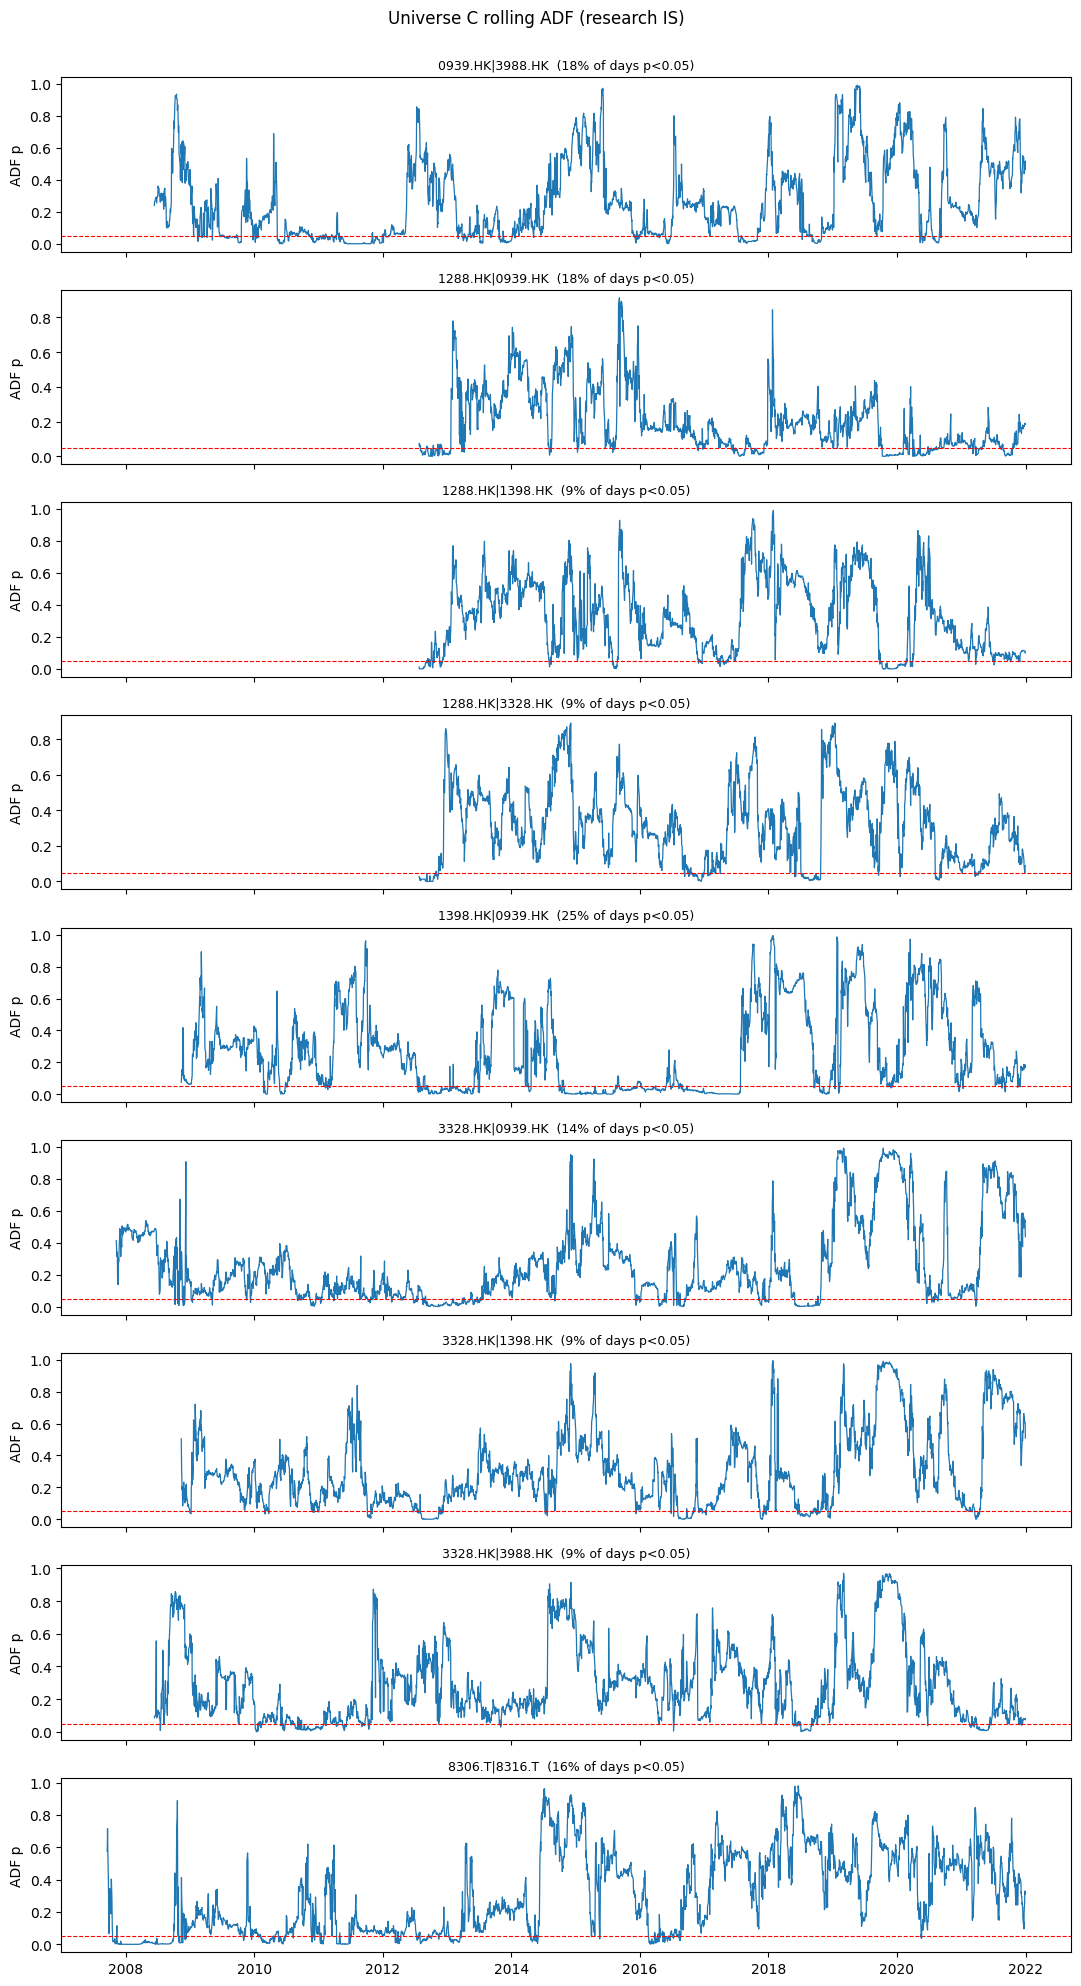

C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


C: union ADF coverage (any pair healthy) = 60.4%


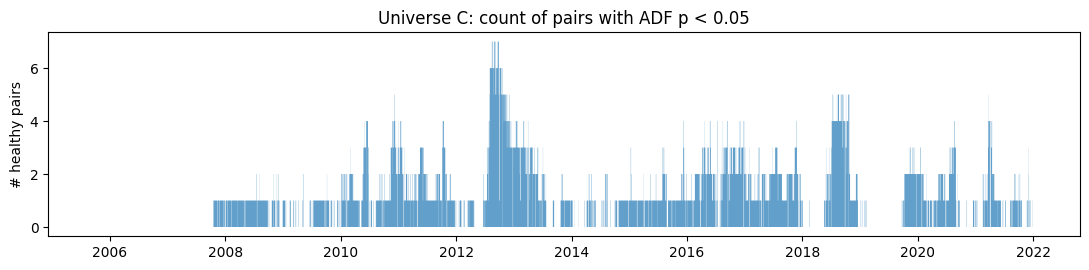

C: pairwise Jaccard overlap of healthy-ADF days


C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,0939.HK|3988.HK,1288.HK|0939.HK,1288.HK|1398.HK,1288.HK|3328.HK,1398.HK|0939.HK,3328.HK|0939.HK,3328.HK|1398.HK,3328.HK|3988.HK,8306.T|8316.T
0939.HK|3988.HK,1.00,0.09,0.00,0.07,0.06,0.13,0.05,0.13,0.09
1288.HK|0939.HK,0.09,1.00,0.24,0.14,0.13,0.14,0.14,0.03,0.05
1288.HK|1398.HK,0.00,0.24,1.00,0.15,0.10,0.06,0.11,0.00,0.05
1288.HK|3328.HK,0.07,0.14,0.15,1.00,0.14,0.21,0.42,0.11,0.05
1398.HK|0939.HK,0.06,0.13,0.10,0.14,1.00,0.19,0.14,0.01,0.12
3328.HK|0939.HK,0.13,0.14,0.06,0.21,0.19,1.00,0.31,0.14,0.10
3328.HK|1398.HK,0.05,0.14,0.11,0.42,0.14,0.31,1.00,0.13,0.07
3328.HK|3988.HK,0.13,0.03,0.00,0.11,0.01,0.14,0.13,1.00,0.07
8306.T|8316.T,0.09,0.05,0.05,0.05,0.12,0.10,0.07,0.07,1.00


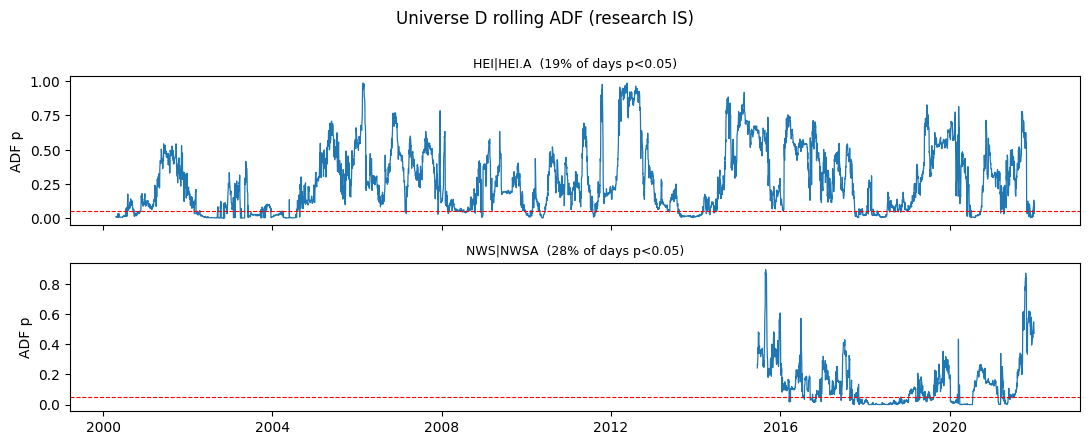

C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


D: union ADF coverage (any pair healthy) = 26.0%


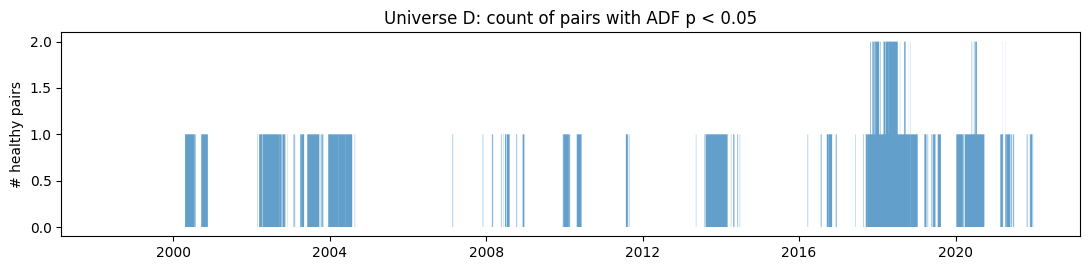

D: pairwise Jaccard overlap of healthy-ADF days


C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,HEI|HEI.A,NWS|NWSA
HEI|HEI.A,1.00,0.11
NWS|NWSA,0.11,1.00


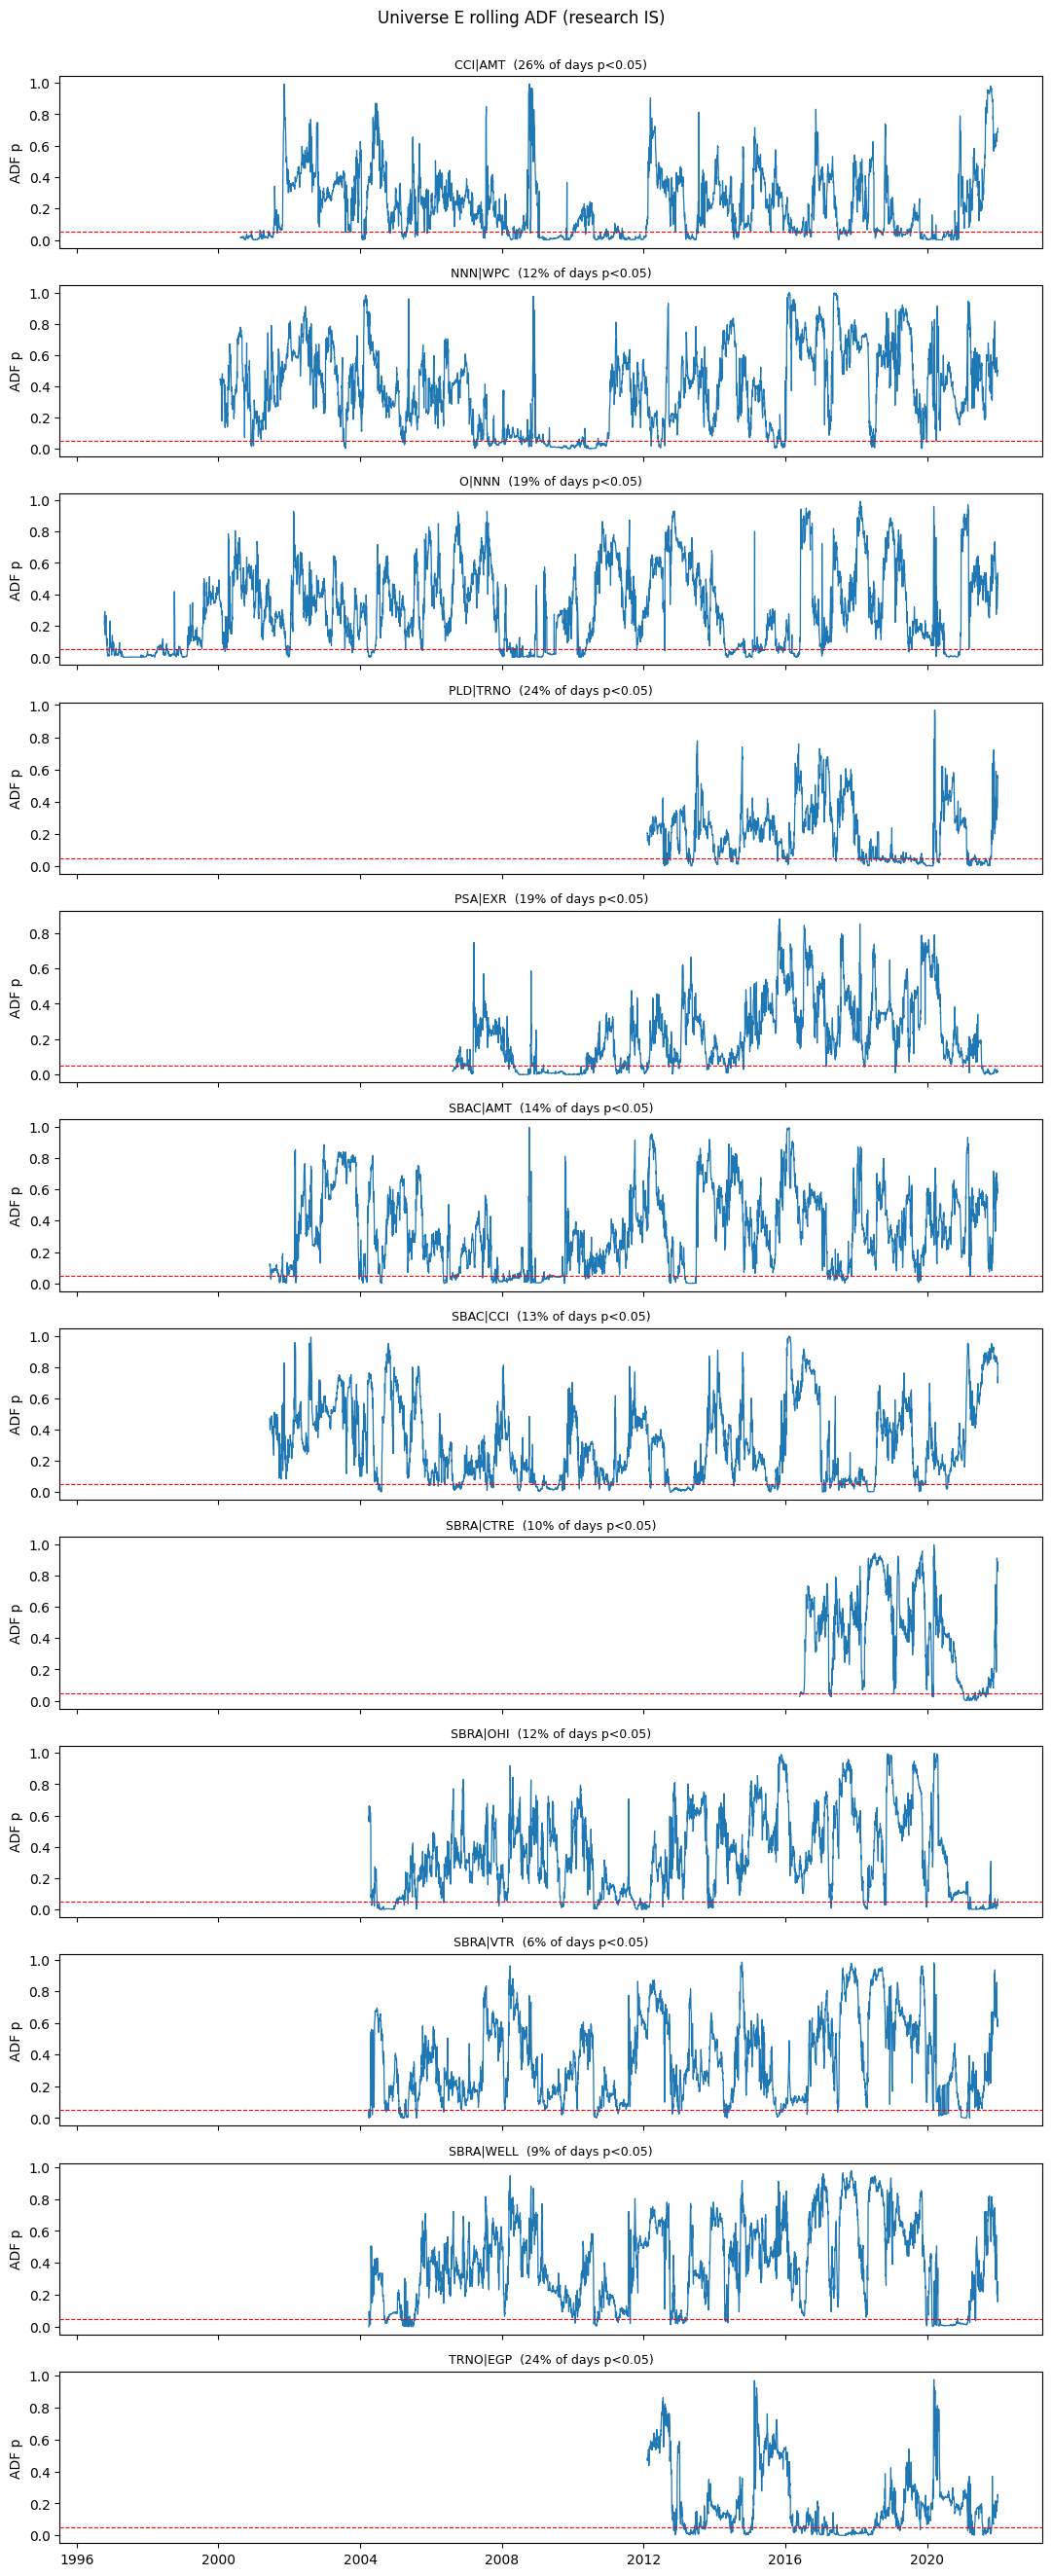

C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


E: union ADF coverage (any pair healthy) = 66.3%


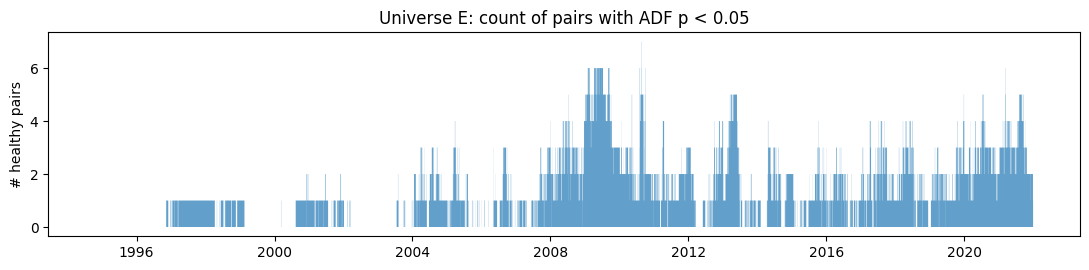

E: pairwise Jaccard overlap of healthy-ADF days


C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,CCI|AMT,NNN|WPC,O|NNN,PLD|TRNO,PSA|EXR,SBAC|AMT,SBAC|CCI,SBRA|CTRE,SBRA|OHI,SBRA|VTR,SBRA|WELL,TRNO|EGP
CCI|AMT,1.00,0.18,0.11,0.12,0.18,0.17,0.13,0.00,0.08,0.06,0.11,0.07
NNN|WPC,0.18,1.00,0.09,0.02,0.26,0.17,0.12,0.00,0.05,0.06,0.03,0.01
O|NNN,0.11,0.09,1.00,0.01,0.15,0.12,0.08,0.00,0.00,0.04,0.08,0.05
PLD|TRNO,0.12,0.02,0.01,1.00,0.05,0.03,0.07,0.14,0.14,0.01,0.04,0.15
PSA|EXR,0.18,0.26,0.15,0.05,1.00,0.20,0.14,0.03,0.15,0.05,0.03,0.04
SBAC|AMT,0.17,0.17,0.12,0.03,0.20,1.00,0.27,0.00,0.02,0.01,0.03,0.11
SBAC|CCI,0.13,0.12,0.08,0.07,0.14,0.27,1.00,0.01,0.04,0.03,0.07,0.16
SBRA|CTRE,0.00,0.00,0.00,0.14,0.03,0.00,0.01,1.00,0.17,0.06,0.07,0.09
SBRA|OHI,0.08,0.05,0.00,0.14,0.15,0.02,0.04,0.17,1.00,0.08,0.07,0.08
SBRA|VTR,0.06,0.06,0.04,0.01,0.05,0.01,0.03,0.06,0.08,1.00,0.26,0.00


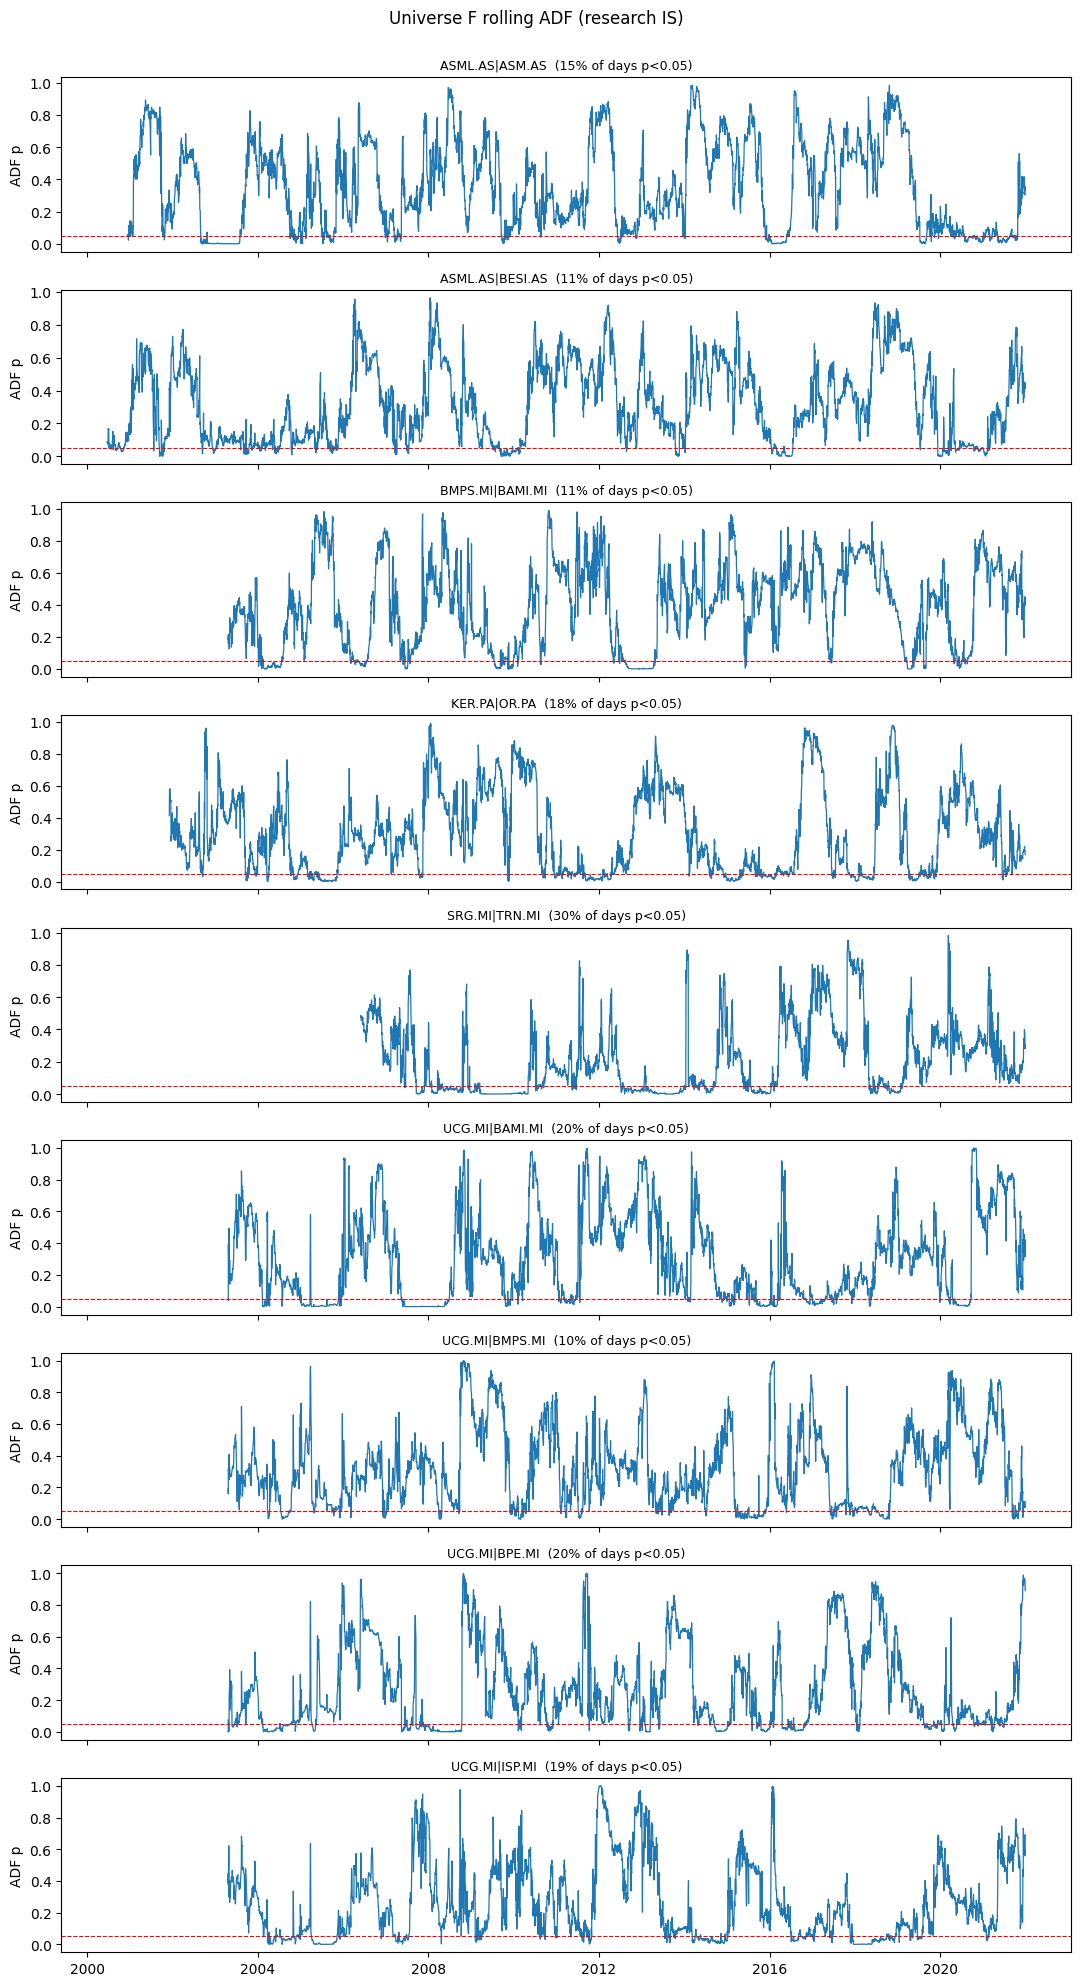

C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


F: union ADF coverage (any pair healthy) = 70.1%


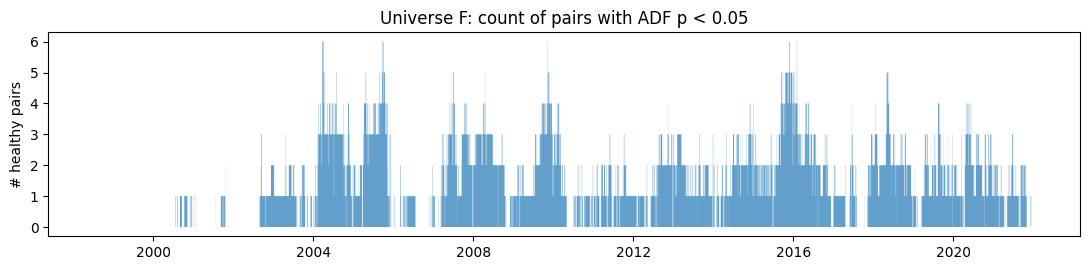

F: pairwise Jaccard overlap of healthy-ADF days


C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\build\__editable__.trading_portfolio-0.1.0-py3-none-any\strategies\s2_coint\metrics.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,ASML.AS|ASM.AS,ASML.AS|BESI.AS,BMPS.MI|BAMI.MI,KER.PA|OR.PA,SRG.MI|TRN.MI,UCG.MI|BAMI.MI,UCG.MI|BMPS.MI,UCG.MI|BPE.MI,UCG.MI|ISP.MI
ASML.AS|ASM.AS,1.00,0.15,0.04,0.10,0.03,0.10,0.03,0.08,0.05
ASML.AS|BESI.AS,0.15,1.00,0.10,0.06,0.09,0.08,0.03,0.10,0.05
BMPS.MI|BAMI.MI,0.04,0.10,1.00,0.03,0.16,0.08,0.03,0.13,0.06
KER.PA|OR.PA,0.10,0.06,0.03,1.00,0.07,0.20,0.10,0.11,0.21
SRG.MI|TRN.MI,0.03,0.09,0.16,0.07,1.00,0.14,0.14,0.16,0.10
UCG.MI|BAMI.MI,0.10,0.08,0.08,0.20,0.14,1.00,0.10,0.23,0.14
UCG.MI|BMPS.MI,0.03,0.03,0.03,0.10,0.14,0.10,1.00,0.09,0.14
UCG.MI|BPE.MI,0.08,0.10,0.13,0.11,0.16,0.23,0.09,1.00,0.19
UCG.MI|ISP.MI,0.05,0.05,0.06,0.21,0.10,0.14,0.14,0.19,1.00


In [9]:
for label in UNIVERSE_LABELS:
    panel = is_panels[label]
    if panel.empty or "adf_pvalue" not in panel.columns:
        continue
    pair_ids = sorted(panel["pair_id"].unique())
    fig, axes = plt.subplots(
        len(pair_ids), 1, figsize=(11, 2.2 * len(pair_ids)), sharex=True, squeeze=False
    )
    for ax, pid in zip(axes[:, 0], pair_ids):
        g = panel.loc[panel["pair_id"] == pid].sort_values("date")
        ax.plot(g["date"], g["adf_pvalue"], lw=0.9)
        ax.axhline(ADF_PVALUE_THRESHOLD, ls="--", lw=0.8, color="red")
        pct = float((g["adf_pvalue"] < ADF_PVALUE_THRESHOLD).mean() * 100.0)
        ax.set_title(f"{pid}  ({pct:.0f}% of days p<{ADF_PVALUE_THRESHOLD})", fontsize=9)
        ax.set_ylabel("ADF p")
    fig.suptitle(f"Universe {label} rolling ADF (research IS)", y=1.001)
    fig.tight_layout()
    plt.show()

    union = adf_union_coverage(panel, pvalue_threshold=ADF_PVALUE_THRESHOLD)
    print(f"{label}: union ADF coverage (any pair healthy) = {union:.1%}")
    masks = adf_health_masks(panel, pvalue_threshold=ADF_PVALUE_THRESHOLD)
    if not masks.empty:
        fig, ax = plt.subplots(figsize=(11, 2.8))
        ax.fill_between(masks.index, masks.sum(axis=1).astype(float), step="mid", alpha=0.7)
        ax.set_ylabel("# healthy pairs")
        ax.set_title(f"Universe {label}: count of pairs with ADF p < {ADF_PVALUE_THRESHOLD}")
        fig.tight_layout()
        plt.show()
        ov = adf_pairwise_overlap(panel, pvalue_threshold=ADF_PVALUE_THRESHOLD)
        print(f"{label}: pairwise Jaccard overlap of healthy-ADF days")
        display(ov.round(2))


## 8. Lock `MANUAL_BOOK` → export artifacts

Fill `MANUAL_BOOK` for E / F in the imports cell (or edit the dict below), then run this cell.
Validation enforces: EG passer only, ≤2 per pool, ≤6 global, no duplicate slots. Fewer than 6 is
allowed. `None` = shelved (A–D). Empty `[]` fails loudly — no auto fallback.

Re-run from **this cell down** after editing the lists.


In [14]:
# Edit here if you prefer not to re-run imports; otherwise set MANUAL_BOOK in section 0.
MANUAL_BOOK["D"] = None
MANUAL_BOOK["E"] = [
    "PLD|TRNO",
    "CCI|AMT",
    "PSA|EXR",
    "O|NNN",
    "TRNO|EGP",
    # "SBAC|CCI" # good but -ve sharpe means may want rejecting
]
MANUAL_BOOK["F"] = [
    "SRG.MI|TRN.MI",
    "UCG.MI|BPE.MI",
    "UCG.MI|ISP.MI",
    "ASML.AS|BESI.AS",
]

selected_by_universe: dict[str, pd.DataFrame] = {}
selected_pairs_by_universe: dict[str, list[tuple[str, str]]] = {}

for label in UNIVERSE_LABELS:
    screened = screened_by_universe[label]
    override = MANUAL_BOOK.get(label)

    if override is None:
        # Shelved / record-only: keep auto suggestion for audit CSV if any passers.
        chosen = auto_by_universe[label].copy()
        mode = "auto_record"
    elif isinstance(override, (list, tuple)) and len(override) == 0:
        raise ValueError(
            f"MANUAL_BOOK[{label!r}] is empty []. Fill EG passers under caps, "
            "or set None for shelved universes."
        )
    else:
        chosen = validate_manual_book(
            list(override),
            screened,
            pool_of_pair=POOL_OF_PAIR[label],
            per_pool_cap=CAP_PER_POOL,
            global_cap=CAP_GLOBAL,
            pvalue_threshold=COINT_PVALUE_THRESHOLD,
        )
        mode = "manual"

    selected_by_universe[label] = chosen
    selected_pairs_by_universe[label] = [
        (str(r.ticker_y), str(r.ticker_x)) for r in chosen.itertuples(index=False)
    ]

    if not screened.empty:
        screened.to_csv(candidates_path(BAR, universe=label, root=ROOT), index=False)
    if not chosen.empty:
        chosen.to_csv(pairs_path(BAR, universe=label, root=ROOT), index=False)

    auto = auto_by_universe[label]
    auto_ids = set(auto["pair_id"].astype(str)) if not auto.empty else set()
    man_ids = set(chosen["pair_id"].astype(str)) if not chosen.empty else set()
    print(f"\n{label}: mode={mode}  locked {len(chosen)} pairs")
    if not chosen.empty:
        print("   by pool:", chosen["pool"].value_counts().to_dict())
        print("   vs auto +", sorted(man_ids - auto_ids), " -", sorted(auto_ids - man_ids))
        display(chosen[["rank", "pair_id", "pool", "pvalue", "discovery_half_life"]])



A: mode=auto_record  locked 0 pairs

B: mode=auto_record  locked 0 pairs

C: mode=auto_record  locked 3 pairs
   by pool: {'HK.cn_banks': 2, 'T.jp_megabanks': 1}
   vs auto + []  - []


,rank,pair_id,pool,pvalue,discovery_half_life
0,1,1398.HK|0939.HK,HK.cn_banks,0.000020,23.401168
1,2,1288.HK|1398.HK,HK.cn_banks,0.000360,28.865318
2,3,8306.T|8316.T,T.jp_megabanks,0.048277,25.302015



D: mode=auto_record  locked 2 pairs
   by pool: {'heico': 1, 'news_corp': 1}
   vs auto + []  - []


,rank,pair_id,pool,pvalue,discovery_half_life
0,1,HEI|HEI.A,heico,0.000437,15.659791
1,2,NWS|NWSA,news_corp,0.012650,12.438238



E: mode=manual  locked 5 pairs
   by pool: {'industrial': 2, 'towers': 1, 'self_storage': 1, 'net_lease': 1}
   vs auto + ['PSA|EXR', 'TRNO|EGP']  - ['SBAC|CCI', 'SBRA|OHI', 'SBRA|VTR']


,rank,pair_id,pool,pvalue,discovery_half_life
0,1,PLD|TRNO,industrial,8.323206e-03,21.285427
1,2,CCI|AMT,towers,3.083666e-08,21.380019
2,3,PSA|EXR,self_storage,3.232805e-02,13.250798
3,4,O|NNN,net_lease,5.201699e-04,16.631919
4,5,TRNO|EGP,industrial,4.342814e-02,35.793427



F: mode=manual  locked 4 pairs
   by pool: {'MI.it_banks': 2, 'MI.it_regulated_utilities': 1, 'AS.nl_semis': 1}
   vs auto + ['UCG.MI|ISP.MI']  - ['ASML.AS|ASM.AS', 'KER.PA|OR.PA', 'UCG.MI|BAMI.MI']


,rank,pair_id,pool,pvalue,discovery_half_life
0,1,SRG.MI|TRN.MI,MI.it_regulated_utilities,1.974450e-02,28.002768
1,2,UCG.MI|BPE.MI,MI.it_banks,4.045165e-07,22.125704
2,3,UCG.MI|ISP.MI,MI.it_banks,5.762231e-06,25.628375
3,4,ASML.AS|BESI.AS,AS.nl_semis,1.968128e-02,26.925699


## 9. Universe IS book summary (manual freeze books)

Book-level metrics via `simulate_frozen_book` on the **locked** books from section 8. Short-ban
masks and the fixed `1/6` slot weight are in force. Gross adds fill costs back onto the net series.

`deployed_frac` = `n_pairs / CAP_GLOBAL` so a 3-pair book (D) is not read as a full 6-slot sleeve.
Do not use per-pair Sharpe to pick pairs — that peeks at the metric you optimize.

**How to read it.** `ann_sharpe_gross` ≫ 0 with `ann_sharpe_net` ≤ 0 means costs ate the edge; both
≤ 0 means there was no edge to begin with (that was C). Rank on net Sharpe, and prefer negative
`corr_to_s1` over a small positive one.


In [15]:
from backtest.s2_coint.research import (
    n_trials_local,
    n_trials_stack,
    register_hypothesis_arms,
)

s1_weekly = load_s1_period_returns(S1_RETURNS_PATH)
if s1_weekly.empty:
    print("NOTE: s1_period_returns.parquet missing - corr_to_s1 will be NaN")

HYP_ID = "H-001"
UNIVERSE_CONFIGS = {u: u for u in UNIVERSE_LABELS}
register_hypothesis_arms(HYP_ID, list(UNIVERSE_CONFIGS.keys()), overwrite=True)
_n_loc = n_trials_local(UNIVERSE_CONFIGS)
_n_stk = n_trials_stack(HYP_ID, UNIVERSE_CONFIGS)

rows = []
for label in UNIVERSE_LABELS:
    panel = is_panels[label]
    chosen = selected_by_universe[label]
    if panel.empty or chosen.empty:
        rows.append(
            {
                "universe": label,
                "n_pairs": 0,
                "deployed_frac": 0.0,
                "ann_sharpe_gross": float("nan"),
                "ann_sharpe_net": float("nan"),
                "max_drawdown": float("nan"),
                "corr_to_s1": float("nan"),
                "n_days": 0,
                "shelved": label in SHELVED_UNIVERSES,
            }
        )
        continue
    book_ids = list(chosen["pair_id"].astype(str))
    book_panel = panel.loc[panel["pair_id"].astype(str).isin(book_ids)].copy()
    book = simulate_frozen_book(book_panel, book_ids, BOOK_CFG)
    net = book["returns"]
    gross = gross_returns_from_net(net, book.get("trades", pd.DataFrame()))
    m_net = metrics_from_returns_inference(
        net, n_trials_local=_n_loc, n_trials_stack=_n_stk
    )
    n_pairs = int(len(chosen))
    rows.append(
        {
            "universe": label,
            "n_pairs": n_pairs,
            "deployed_frac": float(n_pairs) * float(SLOT_WEIGHT),
            "ann_sharpe_gross": metrics_from_returns(gross)["ann_sharpe"],
            "ann_sharpe_net": m_net["ann_sharpe"],
            "max_drawdown": m_net["max_drawdown"],
            "corr_to_s1": corr_to_s1(net, s1_weekly),
            "psr": m_net["psr"],
            "dsr_local": m_net["dsr_local"],
            "dsr_stack": m_net["dsr_stack"],
            "n_days": m_net["n_days"],
            "shelved": label in SHELVED_UNIVERSES,
        }
    )

book_summary = pd.DataFrame(rows)
print("Universe IS book summary (research IS only):")
display(book_summary)

eligible = book_summary.loc[~book_summary["shelved"]].dropna(subset=["ann_sharpe_net"])
if eligible.empty:
    print("\nNo selectable universe produced a book - nothing to freeze.")
else:
    print("\nSelectable universes ranked by net Sharpe (corr shown, not scored):")
    display(
        eligible.sort_values("ann_sharpe_net", ascending=False)[
            [
                "universe",
                "n_pairs",
                "deployed_frac",
                "ann_sharpe_net",
                "ann_sharpe_gross",
                "max_drawdown",
                "corr_to_s1",
                "psr",
                "dsr_local",
                "dsr_stack",
            ]
        ]
    )


Universe IS book summary (research IS only):


,universe,n_pairs,deployed_frac,ann_sharpe_gross,ann_sharpe_net,max_drawdown,corr_to_s1,n_days,shelved,psr,dsr_local,dsr_stack
0,A,0,0.000000,NaN,NaN,NaN,NaN,0,True,NaN,NaN,NaN
1,B,0,0.000000,NaN,NaN,NaN,NaN,0,True,NaN,NaN,NaN
2,C,3,0.500000,2.854873,-0.616278,-0.217162,-0.091664,4218,True,0.0,0.0,0.0
3,D,2,0.333333,0.886869,0.419635,-0.036296,0.124824,5960,True,0.0,1.0,1.0
4,E,5,0.833333,1.095036,0.529958,-0.063746,-0.069783,6849,False,0.0,1.0,1.0
5,F,4,0.666667,1.542467,0.396194,-0.114729,0.101819,6042,False,0.0,1.0,1.0



Selectable universes ranked by net Sharpe (corr shown, not scored):


,universe,n_pairs,deployed_frac,ann_sharpe_net,ann_sharpe_gross,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack
4,E,5,0.833333,0.529958,1.095036,-0.063746,-0.069783,0.0,1.0,1.0
5,F,4,0.666667,0.396194,1.542467,-0.114729,0.101819,0.0,1.0,1.0


## 10. Freeze `UNIVERSE_STAR`

Set the winner from section 9 (E / F only). Also set `BAR_STAR` in H-002 and
`RESEARCH_IS_END_STAR` to the chosen universe's registered end.


In [16]:
from backtest.s2_coint.report import load_star_stack, require_star, save_star_stack
from backtest.s2_coint.research import DEFAULT_STAR_STACK

UNIVERSE_STAR = "E"  # TODO: "E" | "F"
require_star("UNIVERSE_STAR", UNIVERSE_STAR)
if UNIVERSE_STAR in SHELVED_UNIVERSES:
    raise ValueError(
        f"{UNIVERSE_STAR} is shelved (documented failure). Choose from E / F."
    )

stack = load_star_stack(DEFAULT_STAR_STACK)
stack["UNIVERSE_STAR"] = str(UNIVERSE_STAR)
stack["RESEARCH_IS_END_STAR"] = RESEARCH_IS_END[str(UNIVERSE_STAR)]
save_star_stack(DEFAULT_STAR_STACK, stack)
print(
    "wrote UNIVERSE_STAR", stack["UNIVERSE_STAR"],
    "RESEARCH_IS_END_STAR", stack["RESEARCH_IS_END_STAR"],
)

wrote UNIVERSE_STAR E RESEARCH_IS_END_STAR 2021-12-31


## 11. Notes for next hyp

Run `01_data/data_files/s2_coint/s2_pair_panel.ipynb` next with `BOOK_SCOPE = "freeze_only"` to
materialise panels, then H-002 (`BAR_STAR`) → H-003 (`BREAK_STAR`) → H-004 (`BOOK_STAR`) → H-005
(window STARs).

Do not re-pick the universe after seeing downstream bake-offs. If H-003 or H-004 shelves the chosen
universe, come back here and take the next-ranked one — that is a documented step, not a re-pick.
